# WO6c Part D — Does temperature get a shape term?

The temperature version of WO6b Part A's distribution test. WO6b proved that *precipitation*
shape correlation discriminates (U-shaped pairwise distribution, no saturation). Temperature
may not escape the kill condition precipitation escaped: cycles are far more uniformly
sinusoidal, and every Northern-Hemisphere basin peaks in July.

**Decision rule (WO6c Part D):** if the pairwise correlation distribution *saturates near 1.0
within hemisphere*, the temperature lens is `temp_level` + `temp_range` only — no shape term,
and `temp_shape` drops from the schema (its `status: PENDING_PART_D` resolves to excluded).

Cheap and decisive; determines the lens definition before the temp lens is built.

In [1]:
# Cell 1 — Setup
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage

from scripts.shared import db_utils

conn = db_utils.db_connect()
ROOT = Path(db_utils.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'cdop'
OUT.mkdir(parents=True, exist_ok=True)

MONTH_LETTERS = list('JFMAMJJASOND')
print("Setup complete.")

Setup complete.


In [2]:
# Cell 2 — Corpus load, L06: monthly arrays + scalars + representative points
# Same load pattern as WO6b Cell 2 (ST_PointOnSurface, not ST_Centroid; -9999 sentinel masked
# against the raw column before scaling). No arid gate here -- see Cell 4.
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

arr = pd.read_sql(
    "SELECT hybas_id, pre_mm_monthly, tmp_dc_monthly, zone_name, biome "
    "FROM public.v_basin06_persist_rev2", conn)
sc = pd.read_sql(
    "SELECT hybas_id, pre_mm_syr, tmp_dc_syr, "
    "ST_Y(ST_PointOnSurface(geom)) AS lat, ST_X(ST_PointOnSurface(geom)) AS lon "
    "FROM public.basin06", conn)
arr['hybas_id'] = arr['hybas_id'].astype(np.int64)
sc['hybas_id']  = sc['hybas_id'].astype(np.int64)
df = arr.merge(sc, on='hybas_id', how='left')

PRE_all = np.array(df['pre_mm_monthly'].tolist(), dtype=float)
TMP_all = np.array(df['tmp_dc_monthly'].tolist(), dtype=float)   # already deg C, per seasonality.py

for col, scale in (('pre_mm_syr', 1.0), ('tmp_dc_syr', 0.1)):
    df[col] = df[col].astype(float)
    df.loc[df[col] == -9999 * scale, col] = np.nan
    df[col] = df[col] * scale

df['pre_total']    = PRE_all.sum(axis=1)
df['tmp_seas_amp'] = TMP_all.max(axis=1) - TMP_all.min(axis=1)

valid = (~np.isnan(PRE_all).any(axis=1) & ~np.isnan(TMP_all).any(axis=1)
         & (df['pre_total'] > 0) & df['tmp_dc_syr'].notna())
valid = valid.to_numpy()

df  = df[valid].reset_index(drop=True)
PRE = PRE_all[valid]
TMP = TMP_all[valid]

print(f"L06 valid: {len(df)} of {len(valid)} basins")

L06 valid: 16338 of 16397 basins


In [3]:
# Cell 3 — Probes (WO6b's set; resolved to L06 basin, positional idx into df)
import warnings; warnings.filterwarnings("ignore", message="pandas only supports SQLAlchemy")

PROBE_POINTS = [
    ('Mombasa',      -4.0435,   39.6682),
    ('Augsburg',     48.3705,   10.8978),
    ('Tbilisi',      41.6938,   44.8015),
    ('Kaifeng',      34.7986,  114.3413),
    ('Timbuktu',     16.8167,   -2.9833),
    ('George Town',   5.4141,  100.3288),
    ('Santiago',    -33.4489,  -70.6693),
    ('Yakutsk',      62.0280,  129.7326),
    ('Nairobi',      -1.2864,   36.8172),
]
PROBE_IDS = [('Somalia', 1060006860), ('Tennessee', 7060610850)]

def resolve_basin(lat, lon):
    row = pd.read_sql(
        "SELECT hybas_id FROM basin06 "
        f"WHERE ST_Within(ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326), geom) "
        "ORDER BY ST_Area(geom::geography) ASC LIMIT 1", conn)
    return None if row.empty else int(row.iloc[0]['hybas_id'])

pos = {h: i for i, h in enumerate(df['hybas_id'].to_numpy())}
rows = []
for name, lat, lon in PROBE_POINTS:
    h = resolve_basin(lat, lon)
    if h is None or h not in pos:
        print(f"  WARNING: {name} unresolved or outside valid corpus"); continue
    rows.append({'probe': name, 'hybas_id': h, 'idx': pos[h]})
for name, h in PROBE_IDS:
    if h not in pos:
        print(f"  WARNING: {name} ({h}) outside valid corpus"); continue
    rows.append({'probe': name, 'hybas_id': h, 'idx': pos[h]})

probes = pd.DataFrame(rows)
probes['lat']          = df.loc[probes['idx'], 'lat'].to_numpy()
probes['tmp_dc_syr']   = df.loc[probes['idx'], 'tmp_dc_syr'].to_numpy()
probes['tmp_seas_amp'] = df.loc[probes['idx'], 'tmp_seas_amp'].to_numpy()
print(probes.to_string())

          probe    hybas_id    idx        lat  tmp_dc_syr  tmp_seas_amp
0       Mombasa  1060008650  10407  -3.850000        25.4           4.1
1      Augsburg  2060461650   7318  47.942879         6.2          17.7
2       Tbilisi  2060616700  13175  41.628883         5.3          21.7
3       Kaifeng  4060675920     45  33.916667        14.8          27.7
4      Timbuktu  1060551560  11524  16.700000        28.6          12.3
5   George Town  4060020990    373   4.785417        26.8           1.0
6      Santiago  6060027290   4245 -33.604558         9.7          11.4
7       Yakutsk  3060350280  15467  61.768750       -10.2          59.6
8       Nairobi  1061184690   6481  -1.337393        19.0           3.9
9       Somalia  1060006860  10194   9.894044        27.5           7.2
10    Tennessee  7060610850   5211  36.412500        14.2          24.3


In [4]:
# Cell 4 — Temperature correlation machinery + low-amplitude note
# Pearson on 12 monthly temp values == cosine on mean-centred vectors (WO6b Cell 4, on temp).
# No arid gate: temperature is defined everywhere. The analogue of the arid gate is LOW SEASONAL
# AMPLITUDE -- an equatorial basin with ~1 deg C annual swing has a temperature "shape" that is
# noise, exactly as an arid basin's rainfall shape is. We flag it, not gate on it, so Part D.3
# can measure whether it matters.

def row_normalise(V):
    """Mean-centre each row, then scale to unit norm. Zero-variance rows -> NaN."""
    Vc = V - V.mean(axis=1, keepdims=True)
    n  = np.linalg.norm(Vc, axis=1, keepdims=True)
    n  = np.where(n == 0, np.nan, n)
    return Vc / n

ZT_all = row_normalise(TMP)                 # (N,12) mean-centred unit temp curves
flat_t = np.isnan(ZT_all).any(axis=1)       # exactly-flat temp (expected ~none)
amp    = df['tmp_seas_amp'].to_numpy()

out = [f"corpus: {len(df)} basins",
       f"exactly-flat temp profiles (zero variance): {int(flat_t.sum())}",
       "",
       "temperature seasonal amplitude (max-min monthly, deg C) percentiles:"]
for q in [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]:
    out.append(f"  p{q:<3d} {np.percentile(amp, q):6.2f}")
for lo in (1.0, 2.0, 3.0):
    out.append(f"  share with amplitude < {lo:.0f} C: {100*(amp < lo).mean():.1f}%")
print("\n".join(out))

corpus: 16338 basins
exactly-flat temp profiles (zero variance): 0

temperature seasonal amplitude (max-min monthly, deg C) percentiles:
  p0     0.40
  p1     0.90
  p5     1.60
  p10    2.70
  p25    8.00
  p50   17.60
  p75   30.30
  p90   39.40
  p95   43.40
  p99   53.40
  p100  61.60
  share with amplitude < 1 C: 1.1%
  share with amplitude < 2 C: 7.2%
  share with amplitude < 3 C: 11.1%


In [5]:
# Cell 5 — Part D.1: pairwise TEMPERATURE correlation distribution (the kill-condition test)
# WO6c Part D: "if the distribution saturates near 1.0 within hemisphere, the temperature lens
# is level-band plus range-band only." This is WO6b Cell 5 (precip Part A) run on temperature.
# One print -- successive print() calls overwrite each other in PyCharm.
rng = np.random.default_rng(0)
SAMPLE_N = 4000
eligible_t = np.where(~flat_t)[0]
samp = rng.choice(eligible_t, size=min(SAMPLE_N, len(eligible_t)), replace=False)
ZTs  = ZT_all[samp]

Cm = ZTs @ ZTs.T
iu = np.triu_indices(len(samp), k=1)
pair_corr = Cm[iu]

lat_s  = df.loc[samp, 'lat'].to_numpy()
north  = lat_s > 0
same_h = (north[:, None] == north[None, :])[iu]

out = [f"pairs: {len(pair_corr):,} from {len(samp)} sampled basins", "",
       "pairwise TEMP correlation percentiles (all pairs):"]
for q in [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]:
    out.append(f"  p{q:<3d} {np.percentile(pair_corr, q): .3f}")
out += ["", f"mean {pair_corr.mean(): .3f}   sd {pair_corr.std(): .3f}", ""]
for tag, m in (("same-hemisphere", same_h), ("cross-hemisphere", ~same_h)):
    pc = pair_corr[m]
    out.append(f"{tag} ({m.sum():,} pairs): mean {pc.mean(): .3f}  sd {pc.std(): .3f}  "
               f"median {np.median(pc): .3f}")
    out.append(f"    share > 0.90: {100*(pc > 0.90).mean():5.1f}%   "
               f"> 0.95: {100*(pc > 0.95).mean():5.1f}%   > 0.99: {100*(pc > 0.99).mean():5.1f}%")
print("\n".join(out))

pairs: 7,998,000 from 4000 sampled basins

pairwise TEMP correlation percentiles (all pairs):
  p0   -1.000
  p1   -0.992
  p5   -0.979
  p10  -0.954
  p25  -0.673
  p50   0.630
  p75   0.979
  p90   0.993
  p95   0.996
  p99   0.998
  p100  1.000

mean  0.241   sd  0.795

same-hemisphere (5,140,761 pairs): mean  0.701  sd  0.498  median  0.963
    share > 0.90:  63.3%   > 0.95:  55.4%   > 0.99:  22.7%
cross-hemisphere (2,857,239 pairs): mean -0.586  sd  0.509  median -0.835
    share > 0.90:   0.4%   > 0.95:   0.1%   > 0.99:   0.0%


In [7]:
# Cell 6 — Part D.2: per-probe temperature rank-decay
# Mirror of WO6b Part A rank-decay (spread_r1_r1000), on temperature. If a probe's correlation
# stays ~0.99 out to rank 1000, shape adds no ordering the range/level bands don't already have.
# n>=.95 / n>=.99 count corpus basins clearing those cuts -- a saturated count (thousands) is the
# same finding from the query side. One print.
def temp_corr_against_corpus(idx):
    z = ZT_all[idx]
    c = ZT_all @ z                     # (N,), NaN where a row is flat
    c = np.where(np.isnan(c), -np.inf, c)
    c[idx] = -np.inf                   # drop self
    return c

prows = []
for _, pr in probes.iterrows():
    c  = temp_corr_against_corpus(pr['idx'])
    cs = np.sort(c)[::-1]
    cs = cs[np.isfinite(cs)]
    def at(r): return cs[r-1] if len(cs) >= r else np.nan
    n95 = int((c >= 0.95).sum()); n99 = int((c >= 0.99).sum())
    prows.append((pr['probe'], at(1), at(10), at(100), at(1000),
                  at(1) - at(1000), n95, n99))

out = [f"{'probe':<12}{'r@1':>7}{'r@10':>7}{'r@100':>8}{'r@1000':>9}"
       f"{'spread':>8}{'n>=.95':>8}{'n>=.99':>8}"]
for r in prows:
    out.append(f"{r[0]:<12}{r[1]:7.3f}{r[2]:7.3f}{r[3]:8.3f}{r[4]:9.3f}"
               f"{r[5]:8.3f}{r[6]:8d}{r[7]:8d}")
print("\n".join(out))

probe           r@1   r@10   r@100   r@1000  spread  n>=.95  n>=.99
Mombasa       0.999  0.992   0.968    0.912   0.087     270      12
Augsburg      1.000  1.000   0.999    0.997   0.003    9499    5962
Tbilisi       1.000  0.999   0.999    0.996   0.004    9460    3597
Kaifeng       1.000  1.000   0.999    0.998   0.002    9554    6554
Timbuktu      0.999  0.998   0.992    0.947   0.053     940     130
George Town   0.971  0.952   0.922    0.762   0.209      12       0
Santiago      1.000  0.999   0.997    0.985   0.015    1754     762
Yakutsk       1.000  1.000   0.999    0.997   0.003    8888    4356
Nairobi       1.000  0.987   0.955    0.852   0.147     112       6
Somalia       0.999  0.989   0.986    0.971   0.028    5532       8
Tennessee     1.000  1.000   0.999    0.998   0.002    9503    6429


In [9]:
# Cell 7 — Part D.3: is temperature shape informative, or just redundant / noise?
# Two ways a shape term can be worthless: (a) where amplitude is large, all same-hemisphere curves
# are the same July-peaked sinusoid -> shape is REDUNDANT with range(amplitude)+hemisphere(phase);
# (b) where amplitude is small (tropics), the curve is noise -> shape is UNINFORMATIVE. Bin the
# same-hemisphere sampled pairs by the smaller of the two amplitudes and read correlation per bin.
# One print.
amp_s        = amp[samp]
pair_amp_min = np.minimum(amp_s[iu[0]], amp_s[iu[1]])
pc_same      = pair_corr[same_h]
pa_same      = pair_amp_min[same_h]

bins = [(0, 1), (1, 2), (2, 5), (5, 10), (10, 20), (20, 100)]
out = ["same-hemisphere pairs, correlation by min-amplitude bin (deg C):",
       f"{'amp bin':>10}{'n pairs':>10}{'mean r':>9}{'median r':>10}{'sd r':>8}"]
for lo, hi in bins:
    m = (pa_same >= lo) & (pa_same < hi)
    if m.sum() == 0:
        out.append(f"{f'{lo}-{hi}':>10}{0:>10}{'--':>9}{'--':>10}{'--':>8}"); continue
    pcb = pc_same[m]
    out.append(f"{f'{lo}-{hi}':>10}{int(m.sum()):>10}{pcb.mean():9.3f}"
               f"{np.median(pcb):10.3f}{pcb.std():8.3f}")
print("\n".join(out))

same-hemisphere pairs, correlation by min-amplitude bin (deg C):
   amp bin   n pairs   mean r  median r    sd r
       0-1     94166    0.179     0.175   0.360
       1-2    393439    0.113     0.215   0.524
       2-5    748562    0.020    -0.027   0.639
      5-10    732633    0.641     0.805   0.373
     10-20   1439370    0.938     0.975   0.097
    20-100   1732591    0.984     0.990   0.015


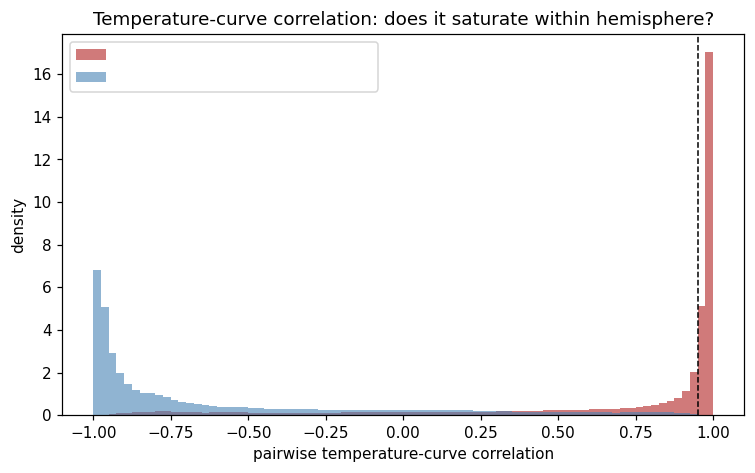

In [10]:
# Cell 8 — Figure: pairwise temperature correlation, within vs cross hemisphere
# PNG-save pattern (CLAUDE.md rubric): facecolor white, savefig, close, display.
print("drawing temp-correlation histogram...")
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.hist(pair_corr[same_h], bins=80, range=(-1, 1), alpha=0.6, color='firebrick',
        label=f'same hemisphere (n={same_h.sum():,})', density=True)
ax.hist(pair_corr[~same_h], bins=80, range=(-1, 1), alpha=0.6, color='steelblue',
        label=f'cross hemisphere (n={(~same_h).sum():,})', density=True)
ax.axvline(0.95, color='black', ls='--', lw=1)
ax.set_xlabel('pairwise temperature-curve correlation', color='black')
ax.set_ylabel('density', color='black')
ax.set_title('Temperature-curve correlation: does it saturate within hemisphere?', color='black')
ax.tick_params(colors='black'); ax.legend()
for s in ax.spines.values(): s.set_color('black')
outpath = OUT / 'wo6c_temp_corr_hist.png'
fig.savefig(outpath, dpi=110, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(IPImage(str(outpath)))

In [11]:
# Cell 9 — Verdict: does temperature get a shape term?
# Decision rule (WO6c Part D): saturation near 1.0 within hemisphere -> level+range only.
# Computed from the measured quantities, not asserted.
sh      = pair_corr[same_h]
sh_med  = float(np.median(sh)); sh_p10 = float(np.percentile(sh, 10))
spreads = np.array([r[5] for r in prows], dtype=float)
med_spread = float(np.nanmedian(spreads))
sat = (sh_med > 0.90) and (med_spread < 0.10)

out = ["WO6c Part D verdict", "-" * 52,
       f"same-hemisphere pairwise corr: median {sh_med:.3f}, p10 {sh_p10:.3f}",
       f"median per-probe rank-decay spread (r@1 - r@1000): {med_spread:.3f}", ""]
if sat:
    out += ["SATURATES within hemisphere.",
            "-> temperature lens = temp_level + temp_range only. NO temp_shape term.",
            "   temp_shape resolves PENDING_PART_D -> EXCLUDED from the schema.",
            "   Within a hemisphere every temp curve is the same July/January-peaked sinusoid,",
            "   so shape correlation is redundant with range (amplitude) + hemisphere (phase);",
            "   where amplitude is small it is noise (Part D.3)."]
else:
    out += ["Does NOT saturate -> temp_shape term is viable; keep it in the schema.",
            "   Check Part D.3 first: confirm the discrimination is not just the low-amplitude",
            "   noise band inflating the spread."]
print("\n".join(out))

WO6c Part D verdict
----------------------------------------------------
same-hemisphere pairwise corr: median 0.963, p10 -0.154
median per-probe rank-decay spread (r@1 - r@1000): 0.015

SATURATES within hemisphere.
-> temperature lens = temp_level + temp_range only. NO temp_shape term.
   temp_shape resolves PENDING_PART_D -> EXCLUDED from the schema.
   Within a hemisphere every temp curve is the same July/January-peaked sinusoid,
   so shape correlation is redundant with range (amplitude) + hemisphere (phase);
   where amplitude is small it is noise (Part D.3).
